In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# !pip install --upgrade certifi

In [3]:
# !pip install gtts pydub audioop-lts
# !pip install --upgrade certifi # added certifi-2025.10.5, though check https://api.msedgeservices.com
import time
import os
import pandas as pd
from collections import defaultdict
from PIL import Image, ImageDraw, ImageFont
from moviepy import ImageClip
from utils_data import (
    load_raw_data, check_dups, filter_df_to_vocab_of_interest, 
    fill_default_settings, delete_previous_attempt_files
    )
from utils_video import (
    combine_clips_with_audio_to_create_video, create_icon_from_slide,
    draw_word_index, draw_logo, draw_previous_word, draw_previous_sent,
    draw_vocab_based_on_format, generate_intro_slide,
    generate_word_list_slide, generate_outro_slide,
    fill_default_video_configs
)
from utils_audio import (
    create_tts_files_for_one_vocab_word, compute_pinyin_and_create_recordings,
    combine_audio_files_and_compute_durations,
    generate_nonvocab_audio_and_compute_durations, create_final_audio_from_each_word_and_nonvocab
)
hanzi_font_path = '/System/Library/Fonts/STHeiti Medium.ttc'
pd.options.display.max_columns = 100
pd.options.display.max_rows = 130

In [4]:
# reload configs
from configs.v050_china_tourist_attractions import (
    data_settings, output_path,
    video_configs,
    nonvocab_slides, subtitle_text_configs,
    DEFAULT_TEXT_PROPERTIES,
)
if subtitle_text_configs is not None:
    subtitle_text_configs['font'] = ImageFont.truetype(subtitle_text_configs['font_name'], subtitle_text_configs['font_size'])

In [5]:
truly_load_data = False
to_delete = True

# 0. Create dataframe of settings

In [6]:
# Fill in default data settings
data_settings = fill_default_settings(data_settings)

# Fill in default video configs
video_configs = fill_default_video_configs(video_configs)

# Create folder for non-audio recordings for this project
project_artifacts_folder = f"{output_path}{data_settings['recording_name']}"
data_settings['audio_path'] = f"{project_artifacts_folder}/audio_{data_settings['filename_suffix']}.mp3"
data_settings['video_path'] = f"{project_artifacts_folder}/video_{data_settings['filename_suffix']}.mp4"

# Create folder if not exists, and delete previous files if desired
if not os.path.exists(project_artifacts_folder):
    os.mkdir(project_artifacts_folder)
if to_delete:
    delete_previous_attempt_files(project_artifacts_folder, data_settings)

# Create folders for audio tts
voice_name_keys = ['voice_name_zh', 'voice_name_en', 'voice_name_convo']
for vnk in voice_name_keys:
    if vnk in data_settings:
        if isinstance(data_settings[vnk], dict):
            for speaker, voice_name in data_settings[vnk].items():
                tts_path = f"output/tts/{voice_name}"
                if not os.path.exists(tts_path):
                    os.mkdir(tts_path)
        else:
            voice_name = data_settings[vnk]
            tts_path = f"output/tts/{voice_name}"
            if not os.path.exists(tts_path):
                os.mkdir(tts_path)

data_settings

{'recording_id': 'cn_only_sent',
 'silent_components': True,
 'filename_suffix': 'china_tourist_attractions',
 'types_allowed': ['word',
  'prefix',
  'suffix',
  'abbreviation',
  'multi_word',
  'verb_ending',
  'phrase',
  'speak_phrase',
  'saying',
  'idiom',
  'modal particle',
  'proper noun'],
 'max_priority': 5,
 'min_known_english_prompt': 2,
 'cat_v3_allowed': ['my_china_spots'],
 'sort_keys': ['priority', 'pinyin'],
 'sort_asc': [True, True],
 'min_priority': 1,
 'max_known_english_prompt': 6,
 'min_known_pinyin_prompt': 1,
 'max_known_pinyin_prompt': 6,
 'min_combo_quality': 10,
 'categories_allowed': None,
 'categories_not_allowed': None,
 'categories2_allowed': None,
 'categories2_not_allowed': None,
 'cat_v3_not_allowed': None,
 'cat2_v3_allowed': None,
 'cat2_v3_not_allowed': None,
 'source1_values_allowed': None,
 'types_allowed_str': '',
 'min_adu': 3,
 'min_per': 3,
 'min_date': '2025-01-01',
 'max_date': '2095-01-01',
 'contains_character': None,
 'exclude_words': 

# 1. Load data

In [7]:
if truly_load_data:
    df_all_vocab = load_raw_data()
    df_all_vocab.to_csv('static/latest_data.csv', index=False)
else:
    df_all_vocab = pd.read_csv('static/latest_data.csv')
    print('!!!!!!!! WARNING: not truly loading data !!!!!!!!')

df_dups = check_dups(df_all_vocab)
print(df_all_vocab.shape)
df_all_vocab.head(3)

!!!!!!!! WARNING: not truly loading data !!!!!!!!
(6882, 37)


,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic
0,1,房贷,fáng dài,mortgage,word,1.0,life,NaN,Finance & Economy,NaN,NONE,1.0,1.0,2.0,1.0,房子,house,贷款,loan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,他每个月都要还房贷,Ta měi gè yuè dōu yào huán fángdài,He has to pay his mortgage every month,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN
1,2,白天,bái tiān,daytime,word,2.0,time,NaN,Time,NaN,1,2.0,1.0,1.0,1.0,白,white,天,day,NaN,NaN,NaN,NaN,NaN,NaN,NaN,白天很热晚上比较凉快,Báitiān hěn rè wǎnshàng bǐjiào liángkuai,It is hot in the daytime and cooler at night,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN
2,3,组成,zǔ chéng,to form;make up,word,3.0,general,NaN,Language & Expression,NaN,2,5.0,5.0,5.0,3.0,组,set,成,become,NaN,NaN,NaN,NaN,NaN,NaN,NaN,水是由氢和氧组成的,Shuǐ shì yóu qīng hé yǎng zǔchéng de,Water is made up of hydrogen and oxygen,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN


In [8]:
print(f'# duplicate vocab: {len(df_dups)}')
df_dups

# duplicate vocab: 0


,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic


# 2. Select data

In [9]:
df_vocab_lists = filter_df_to_vocab_of_interest(df_all_vocab, data_settings)
n_vocab = len(df_vocab_lists)
print(data_settings['recording_name'], n_vocab)
df_vocab_lists.head(3)

0101_cn_only_sent_china_tourist_attractions 89


,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic
0,6883,长城,cháng chéng,"The Great Wall of China, a historic series of ...",proper noun,1.0,NaN,NaN,my_china_spots,NaN,MISSING,5.0,5.0,5.0,3.0,长,long,城墙,city wall,NaN,NaN,NaN,NaN,NaN,NaN,长: long\n城墙: city wall,第一次站在长城上，我被它的规模震撼了。,"dì yī cì zhàn zài cháng chéng shàng, wǒ bèi tā...","The first time I stood on the Great Wall, I wa...",2025-12-30,china places,NaN,NaN,5.0,5.0,5.0,NaN
1,6888,兵马俑,bīng mǎ yǒng,"Terracotta Army (Xi’an), thousands of life-siz...",proper noun,2.0,NaN,NaN,my_china_spots,NaN,MISSING,5.0,5.0,5.0,3.0,士兵,soldier,马,horse,俑,figure buried with the dead,NaN,NaN,NaN,NaN,士兵: soldier\n马: horse\n俑: figure buried with ...,兵马俑展示了秦朝的军事实力。,bīng mǎ yǒng zhǎn shì le qín cháo de jūn shì s...,The Terracotta Warriors show the military powe...,2025-12-30,china places,NaN,NaN,5.0,5.0,5.0,NaN
2,6909,长江,cháng jiāng,"Yangtze River, China’s longest river",proper noun,2.0,NaN,NaN,my_china_spots,NaN,MISSING,5.0,5.0,5.0,4.0,长,long,江,large river,NaN,NaN,NaN,NaN,NaN,NaN,长: long\n江: large river,长江是中国最长的河流。,cháng jiāng shì zhōng guó zuì cháng de hé liú,The Yangtze River is the longest river in China.,2025-12-30,china places,NaN,NaN,5.0,5.0,5.0,NaN


# 3. Create vocabulary audio recordings

In [10]:
# os.remove('output/tts/zh-CN-XiaoyuMultilingualNeural/今天下雨记得带雨衣.mp3')
if data_settings['recording_id'] == '005':
    df_vocab_lists = compute_pinyin_and_create_recordings(df_vocab_lists)

start_time = time.time()
for i_row, row in df_vocab_lists.iterrows():
    print(f"{(time.time()-start_time):.1f}s, row{i_row}")
    create_tts_files_for_one_vocab_word(row, data_settings)

0.0s, row0
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 长城
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, The Great Wall of China, a historic series of fortifications spanning northern China
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 第一次站在长城上，我被它的规模震撼了。
0.0s, row1
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 兵马俑
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, Terracotta Army (Xi’an), thousands of life-sized clay soldiers guarding an emperor’s tomb
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 兵马俑展示了秦朝的军事实力。
0.0s, row2
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 长江
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, Yangtze River, China’s longest river
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 长江是中国最长的河流。
0.0s, row3
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 桂林山水
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, Guilin Scenery (Guangxi), picturesque karst mountains and rivers
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 桂林山水甲天下。
0.0s, row4
0.000s, ALREADY E

## 3b. Compute durations of combined audios for each vocab word

In [11]:
audio_duration_file_name = f"{project_artifacts_folder}/audio_durations_vocab_only.csv"
if os.path.exists(audio_duration_file_name):
    df_vocab_audio_durations = pd.read_csv(audio_duration_file_name)
    print(f"Loaded existing audio durations for {data_settings['recording_name']}, shape {df_vocab_audio_durations.shape}")
else:
    df_vocab_audio_durations = combine_audio_files_and_compute_durations(df_vocab_lists, data_settings)
    df_vocab_audio_durations.to_csv(audio_duration_file_name, index=False)

df_vocab_audio_durations['nonvocab_file_path'] = None
df_vocab_audio_durations['nonvocab_pause_ms'] = None
df_vocab_audio_durations['nonvocab_key'] = None
print(f"Total duration: {df_vocab_audio_durations['combined'].sum()}s")
df_vocab_audio_durations.head(3)

0.31 seconds, recid0101_cn_only_sent_china_tourist_attractions, row 0, 长城
0.29 seconds, recid0101_cn_only_sent_china_tourist_attractions, row 1, 兵马俑
0.28 seconds, recid0101_cn_only_sent_china_tourist_attractions, row 2, 长江
0.28 seconds, recid0101_cn_only_sent_china_tourist_attractions, row 3, 桂林山水
0.29 seconds, recid0101_cn_only_sent_china_tourist_attractions, row 4, 黄河
0.29 seconds, recid0101_cn_only_sent_china_tourist_attractions, row 5, 黄山
0.28 seconds, recid0101_cn_only_sent_china_tourist_attractions, row 6, 九寨沟
0.28 seconds, recid0101_cn_only_sent_china_tourist_attractions, row 7, 丝绸之路
0.28 seconds, recid0101_cn_only_sent_china_tourist_attractions, row 8, 天安门广场
0.28 seconds, recid0101_cn_only_sent_china_tourist_attractions, row 9, 泰山
0.28 seconds, recid0101_cn_only_sent_china_tourist_attractions, row 10, 西湖
0.28 seconds, recid0101_cn_only_sent_china_tourist_attractions, row 11, 张家界
0.28 seconds, recid0101_cn_only_sent_china_tourist_attractions, row 12, 东方明珠
0.29 seconds, recid0101

,chinese,pinyin,english,sentence,sentence_pinyin,sentence_english,slang,phonetic,d_chinese,d_sent,rel_start_chinese,rel_start_sent,sum_theory,combined,video_notes,nonvocab_file_path,nonvocab_pause_ms,nonvocab_key
0,长城,cháng chéng,"The Great Wall of China, a historic series of ...",第一次站在长城上，我被它的规模震撼了。,"dì yī cì zhàn zài cháng chéng shàng, wǒ bèi tā...","The first time I stood on the Great Wall, I wa...",5.0,NaN,1.296,4.008,0.2,1.796,6.604,6.603708,长: long\n城墙: city wall,None,None,None
1,兵马俑,bīng mǎ yǒng,"Terracotta Army (Xi’an), thousands of life-siz...",兵马俑展示了秦朝的军事实力。,bīng mǎ yǒng zhǎn shì le qín cháo de jūn shì s...,The Terracotta Warriors show the military powe...,5.0,NaN,1.440,3.456,0.2,1.940,6.196,6.195708,士兵: soldier\n马: horse\n俑: figure buried with ...,None,None,None
2,长江,cháng jiāng,"Yangtze River, China’s longest river",长江是中国最长的河流。,cháng jiāng shì zhōng guó zuì cháng de hé liú,The Yangtze River is the longest river in China.,5.0,NaN,1.272,2.712,0.2,1.772,5.284,5.283708,长: long\n江: large river,None,None,None


# 4. Create non-vocab audio recordings

In [12]:
df_vocab_audio_durations, audio_filler_variables, nonvocab_slides = generate_nonvocab_audio_and_compute_durations(
    data_settings, df_vocab_audio_durations, nonvocab_slides, project_artifacts_folder)
df_vocab_audio_durations.head()

intro audio already generated: 我的普通话数据库视频 50
outro audio already generated: 如果你有任何问题、建议或反馈，请留言。请点赞并订阅。


,chinese,pinyin,english,sentence,sentence_pinyin,sentence_english,slang,phonetic,d_chinese,d_sent,rel_start_chinese,rel_start_sent,sum_theory,combined,video_notes,nonvocab_file_path,nonvocab_pause_ms,nonvocab_key,end,start,start_chinese,start_sent
0,我的普通话数据库视频 50,wǒ de pǔtōnghuà shùjùkù shìpín 50,My Mandarin Chinese Database Video 50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.740000,NaN,output/videos/0101_cn_only_sent_china_tourist_...,500,intro,3.740000,0.000000,NaN,NaN
1,长城,cháng chéng,"The Great Wall of China, a historic series of ...",第一次站在长城上，我被它的规模震撼了。,"dì yī cì zhàn zài cháng chéng shàng, wǒ bèi tā...","The first time I stood on the Great Wall, I wa...",5.0,NaN,1.296,4.008,0.2,1.796,6.604,6.603708,长: long\n城墙: city wall,None,None,None,10.343708,3.740000,3.940000,5.536000
2,兵马俑,bīng mǎ yǒng,"Terracotta Army (Xi’an), thousands of life-siz...",兵马俑展示了秦朝的军事实力。,bīng mǎ yǒng zhǎn shì le qín cháo de jūn shì s...,The Terracotta Warriors show the military powe...,5.0,NaN,1.440,3.456,0.2,1.940,6.196,6.195708,士兵: soldier\n马: horse\n俑: figure buried with ...,None,None,None,16.539417,10.343708,10.543708,12.283708
3,长江,cháng jiāng,"Yangtze River, China’s longest river",长江是中国最长的河流。,cháng jiāng shì zhōng guó zuì cháng de hé liú,The Yangtze River is the longest river in China.,5.0,NaN,1.272,2.712,0.2,1.772,5.284,5.283708,长: long\n江: large river,None,None,None,21.823125,16.539417,16.739417,18.311417
4,桂林山水,guì lín shān shuǐ,"Guilin Scenery (Guangxi), picturesque karst mo...",桂林山水甲天下。,guì lín shān shuǐ jiǎ tiān xià,Guilin’s scenery is the best under heaven.,5.0,NaN,1.752,2.328,0.2,2.252,5.380,5.379708,桂花: osmanthus\n森林: forest\n山: mountain\n水: water,None,None,None,27.202833,21.823125,22.023125,24.075125


# 5. Combine individual vocab into final audio recording

In [13]:
if not os.path.exists(data_settings['audio_path']):
    create_final_audio_from_each_word_and_nonvocab(df_vocab_audio_durations, data_settings)
else:
    print(f"Final audio already exists at {data_settings['audio_path']}")

8.10s, output/videos/0101_cn_only_sent_china_tourist_attractions/audio_china_tourist_attractions.mp3


# 6. Create images for video

In [14]:
# If don't want to rerun the above cells, then just run this cell to load the audio durations
audio_generation_previous_run = True
if audio_generation_previous_run:
    try:
        df_vocab_audio_durations = pd.read_csv(f"{project_artifacts_folder}/audio_durations_all.csv")
        print(f"{data_settings['recording_name']} loaded")
    except FileNotFoundError:
        print(f"File not found for recording {data_settings['recording_name']}, please run the cell above to generate audio durations.")
df_vocab_audio_durations.head()

0101_cn_only_sent_china_tourist_attractions loaded


,chinese,pinyin,english,sentence,sentence_pinyin,sentence_english,slang,phonetic,d_chinese,d_sent,rel_start_chinese,rel_start_sent,sum_theory,combined,video_notes,nonvocab_file_path,nonvocab_pause_ms,nonvocab_key,end,start,start_chinese,start_sent
0,我的普通话数据库视频 50,wǒ de pǔtōnghuà shùjùkù shìpín 50,My Mandarin Chinese Database Video 50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.740000,NaN,output/videos/0101_cn_only_sent_china_tourist_...,500.0,intro,3.740000,0.000000,NaN,NaN
1,长城,cháng chéng,"The Great Wall of China, a historic series of ...",第一次站在长城上，我被它的规模震撼了。,"dì yī cì zhàn zài cháng chéng shàng, wǒ bèi tā...","The first time I stood on the Great Wall, I wa...",5.0,NaN,1.296,4.008,0.2,1.796,6.604,6.603708,长: long\n城墙: city wall,NaN,NaN,NaN,10.343708,3.740000,3.940000,5.536000
2,兵马俑,bīng mǎ yǒng,"Terracotta Army (Xi’an), thousands of life-siz...",兵马俑展示了秦朝的军事实力。,bīng mǎ yǒng zhǎn shì le qín cháo de jūn shì s...,The Terracotta Warriors show the military powe...,5.0,NaN,1.440,3.456,0.2,1.940,6.196,6.195708,士兵: soldier\n马: horse\n俑: figure buried with ...,NaN,NaN,NaN,16.539417,10.343708,10.543708,12.283708
3,长江,cháng jiāng,"Yangtze River, China’s longest river",长江是中国最长的河流。,cháng jiāng shì zhōng guó zuì cháng de hé liú,The Yangtze River is the longest river in China.,5.0,NaN,1.272,2.712,0.2,1.772,5.284,5.283708,长: long\n江: large river,NaN,NaN,NaN,21.823125,16.539417,16.739417,18.311417
4,桂林山水,guì lín shān shuǐ,"Guilin Scenery (Guangxi), picturesque karst mo...",桂林山水甲天下。,guì lín shān shuǐ jiǎ tiān xià,Guilin’s scenery is the best under heaven.,5.0,NaN,1.752,2.328,0.2,2.252,5.380,5.379708,桂花: osmanthus\n森林: forest\n山: mountain\n水: water,NaN,NaN,NaN,27.202833,21.823125,22.023125,24.075125


## 6a. Vocab words

Drawing 0: 长城
reduced font size to 49
reduced font size to 48
reduced font size to 47
reduced font size to 46
reduced font size to 45
reduced font size to 44
reduced font size to 43
reduced font size to 42
reduced font size to 41
reduced font size to 40
reduced font size to 39
reduced font size to 38
reduced font size to 37
reduced font size to 36
reduced font size to 35
reduced font size to 34
reduced font size to 33
reduced font size to 32
reduced font size to 31
Drawing 1: 兵马俑
reduced font size to 49
reduced font size to 48
reduced font size to 47
reduced font size to 46
reduced font size to 45
reduced font size to 44
reduced font size to 43
reduced font size to 42
reduced font size to 41
reduced font size to 40
reduced font size to 39
reduced font size to 38
reduced font size to 37
reduced font size to 36
reduced font size to 35
reduced font size to 34
reduced font size to 33
reduced font size to 32
reduced font size to 31
reduced font size to 30
reduced font size to 29
reduced fon


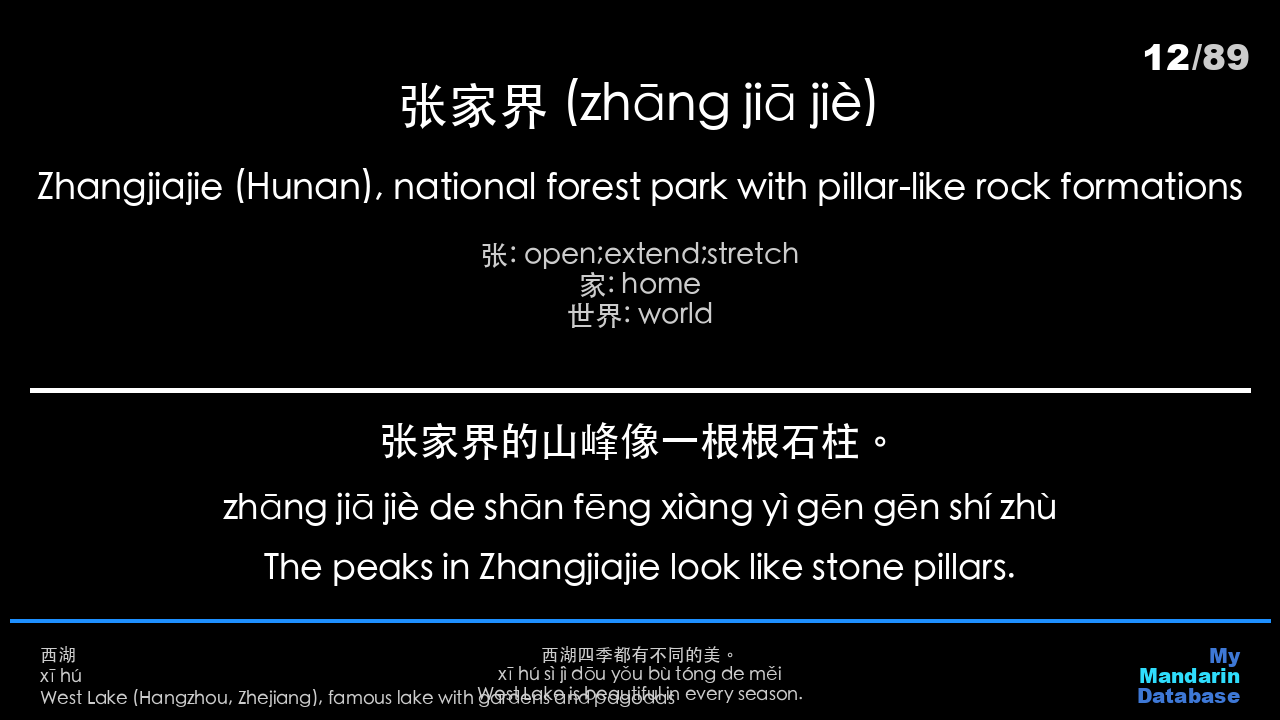

In [15]:
# Overall initializations
clips = []
previous_word = ''
previous_sent = ''

# Create folder to hold slide images
slides_path = f"{project_artifacts_folder}/slides"
if not os.path.exists(slides_path):
    os.mkdir(slides_path)

# Fill in defaults for any missing properties
for config_key, default_config_value in DEFAULT_TEXT_PROPERTIES.items():
    for vocab_slide_id, vocab_slide_settings in video_configs['vocab_slide'].items():
        if config_key not in vocab_slide_settings.keys():
            video_configs['vocab_slide'][vocab_slide_id][config_key] = default_config_value

# Iterate through each word
df_audio_durations_words_only = df_vocab_audio_durations.dropna(subset='sum_theory').reset_index(drop=True)
for word_idx, row in df_audio_durations_words_only.iterrows():
    # Initialize image
    print(f'Drawing {word_idx}: {row["chinese"]}')
    current_image_file_path = f"{slides_path}/{row['chinese']}"
    img = Image.new("RGB", video_configs['bg_size'], color=video_configs['bg_color'])
    draw = ImageDraw.Draw(img)
    
    # Header/Footer texts
    draw_word_index(draw, video_configs, n_vocab, word_idx)
    if 'logo' in video_configs.keys():
        draw_logo(draw, video_configs)
    if 'previous_word' in video_configs.keys():
        draw_previous_word(draw, video_configs, previous_word)
    if 'previous_sent' in video_configs.keys():
        draw_previous_sent(draw, video_configs, previous_sent)
    draw.line([
        (video_configs['footer_line']['x'], video_configs['bg_size'][1] - video_configs['footer_line']['y']),
        (video_configs['bg_size'][0] - video_configs['footer_line']['x'], video_configs['bg_size'][1] - video_configs['footer_line']['y'])],
        fill=video_configs['footer_line']['color'],
        width=video_configs['footer_line']['width'],
        joint=None)
    
    # Update previous
    previous_word = f"{row['chinese']}\n{row['pinyin']}\n{row['english']}"
    if 'previous_sent' in video_configs.keys():
        previous_sent = f"{row['sentence']}\n{row['sentence_pinyin']}\n{row['sentence_english']}"

    # Draw vocab depending on recording ID
    draw_vocab_based_on_format(data_settings['recording_id'], row, video_configs, current_image_file_path, img, draw, clips)

my_img = clips[23]
my_img.display_in_notebook()

# 7. Create non-vocab slides


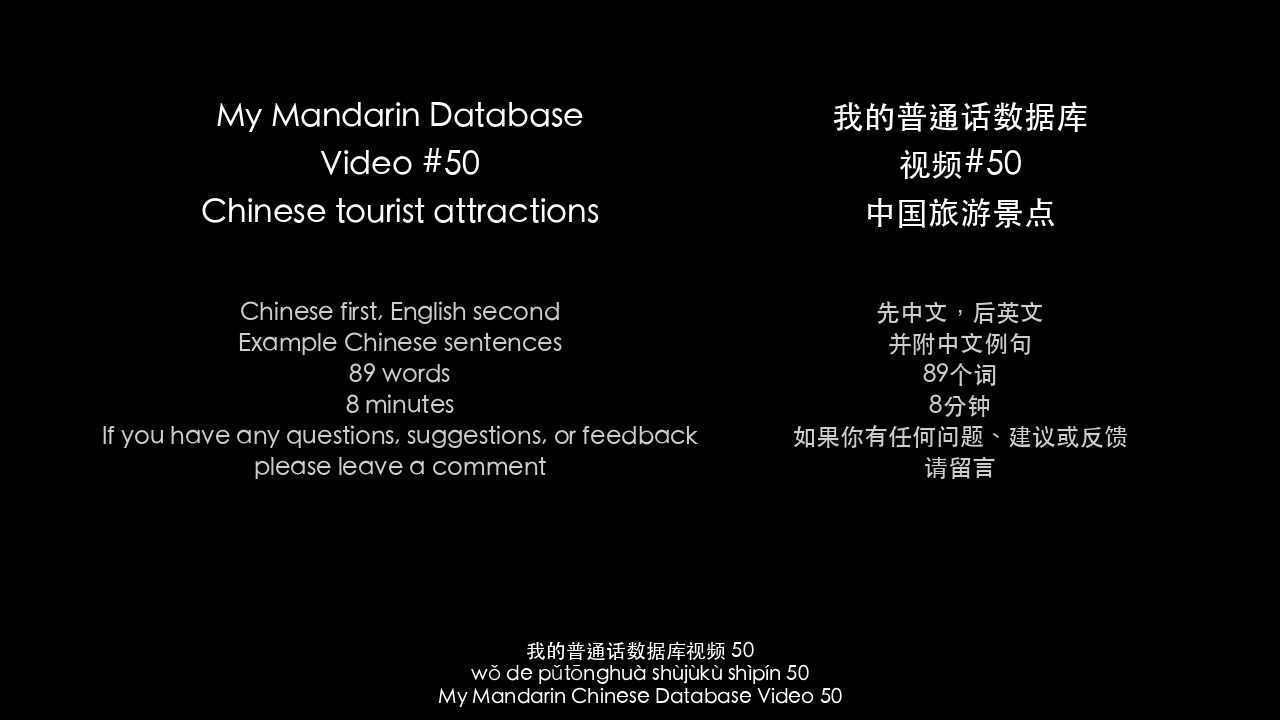

In [16]:
if nonvocab_slides is not None:
    if 'intro' in nonvocab_slides.keys():
        img = generate_intro_slide(video_configs, nonvocab_slides['intro'], subtitle_text_configs, audio_filler_variables)
        img.save(f"{project_artifacts_folder}/intro.png")
        my_img = ImageClip(f"{project_artifacts_folder}/intro.png", duration=1).with_start(0)
my_img.display_in_notebook()


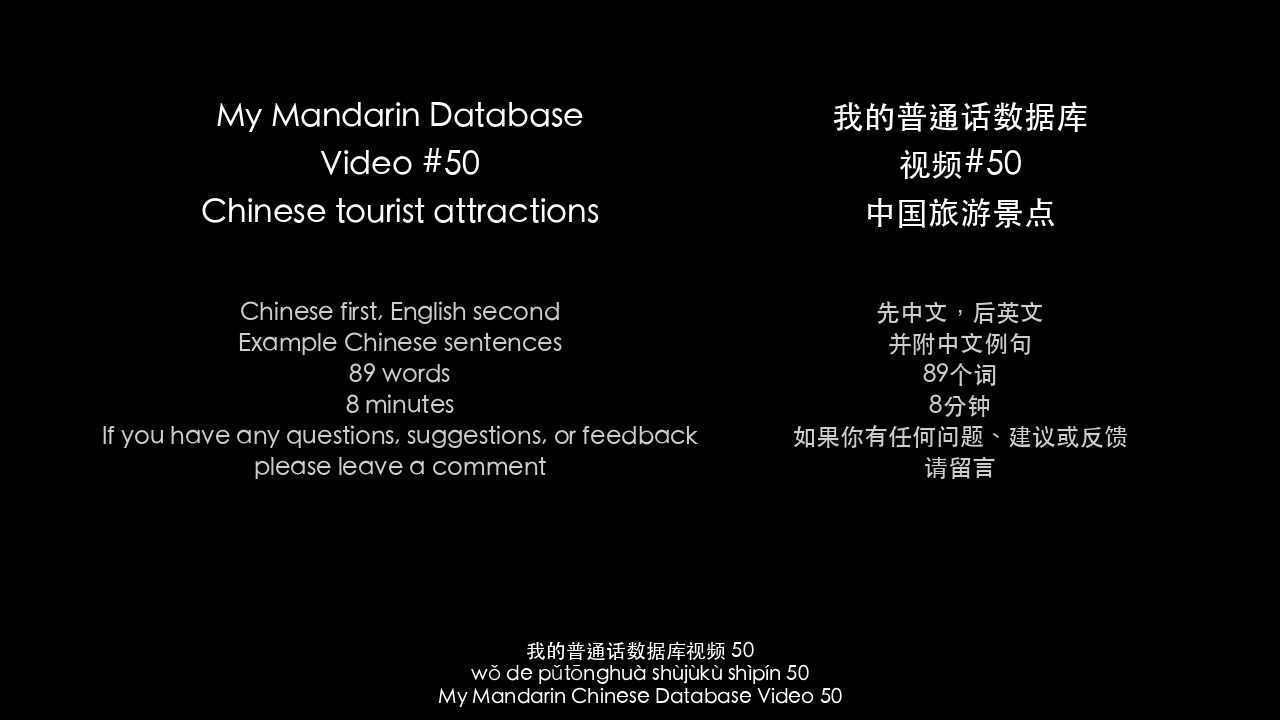

In [17]:
if nonvocab_slides is not None:
    if 'word_list' in nonvocab_slides.keys():
        img = generate_word_list_slide(video_configs, nonvocab_slides['word_list'], subtitle_text_configs, df_audio_durations_words_only)
        img.save(f"{project_artifacts_folder}/word_list.png")
        my_img = ImageClip(f"{project_artifacts_folder}/word_list.png", duration=1).with_start(0)
my_img.display_in_notebook()

In [18]:
# nonvocab_slides['outro'] = {
#         'chinese': '如果你有任何问题、建议或反馈，请留言。请点赞并订阅。',
#         'pinyin': 'Rúguǒ nǐ yǒu rènhé wèntí, jiànyì huò fǎnkuì, qǐng liúyán. Qǐng diǎn zàn bìng dìngyuè.',
#         'english': 'If you have any questions, suggestions, or feedback, please leave a comment. Please like and subscribe.',
#         'clip_index': -1,
#         'change_index': None,
#         'pause_ms': 500,

#         'y_top': 10,
#         'y_bottom': 85,
#         'x_top': 10,
#         'spacing': 0,
#         'font_size': 13,
#         'fill': '#FFFFFF',
#         'align': 'left',
#         'col_space': 2,
#         'col_space_big': 10,
#         'definition_configs':{
#             'chinese': {'x_offset': 0, 'x_max': 70, 'font_path': hanzi_font_path},
#             'pinyin': {'x_offset': None, 'x_max': 155, 'font_path': hanzi_font_path},
#             'english': {'x_offset': None, 'x_max': 390, 'font_path': hanzi_font_path},
#         }
# }

reduced font size to 12
reduced font size to 11
reduced font size to 10
reduced font size to 12
reduced font size to 11
reduced font size to 10
reduced font size to 9
reduced font size to 8
reduced font size to 12
reduced font size to 12
reduced font size to 11
reduced font size to 10
reduced font size to 9
reduced font size to 8
reduced font size to 12
reduced font size to 11
reduced font size to 10
reduced font size to 12
reduced font size to 12
reduced font size to 11
reduced font size to 12
reduced font size to 12
reduced font size to 11
reduced font size to 12
reduced font size to 11
reduced font size to 12
reduced font size to 11
reduced font size to 10
reduced font size to 12
reduced font size to 11
reduced font size to 12
reduced font size to 11
reduced font size to 12
reduced font size to 11
reduced font size to 10
reduced font size to 9
reduced font size to 12
reduced font size to 11
reduced font size to 10
reduced font size to 12
reduced font size to 11
reduced font size to 


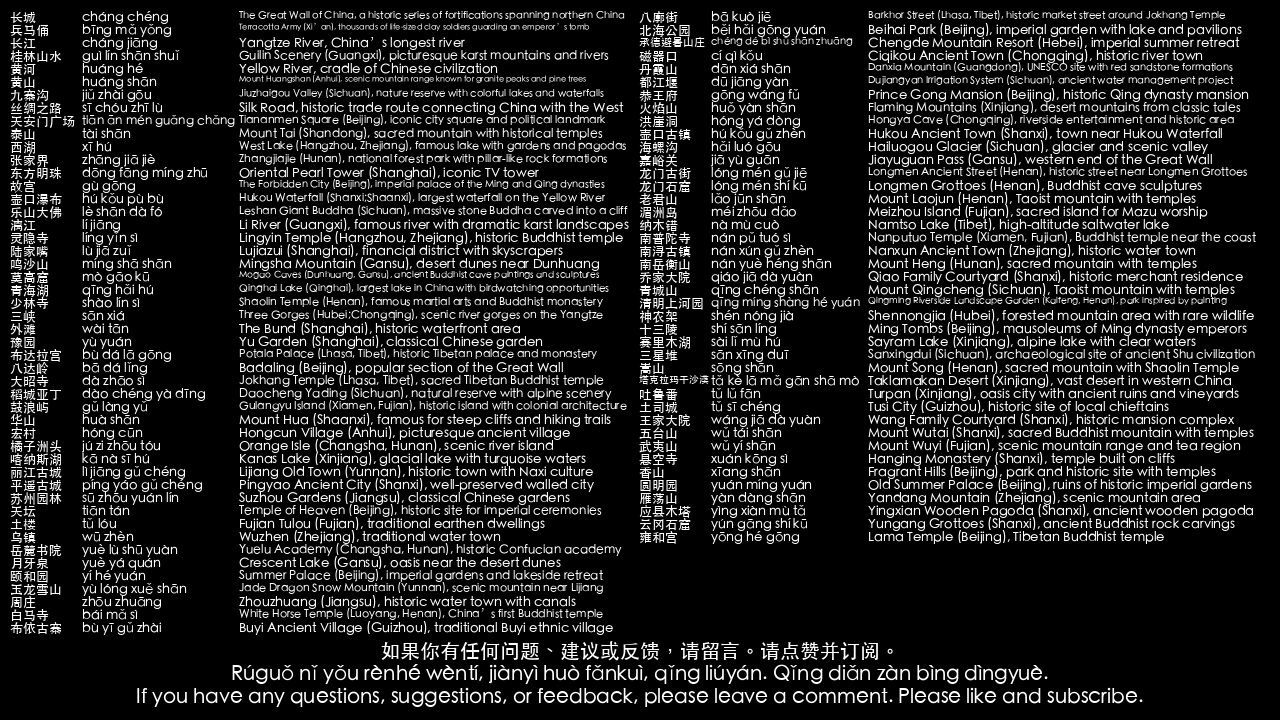

In [19]:
if nonvocab_slides is not None:
    if 'outro' in nonvocab_slides.keys():
        img = generate_outro_slide(video_configs, nonvocab_slides['outro'], subtitle_text_configs, df_audio_durations_words_only)
        img.save(f"{project_artifacts_folder}/outro.png")
        my_img = ImageClip(f"{project_artifacts_folder}/outro.png", duration=1).with_start(0)
my_img.display_in_notebook()

# 8. Create video icon


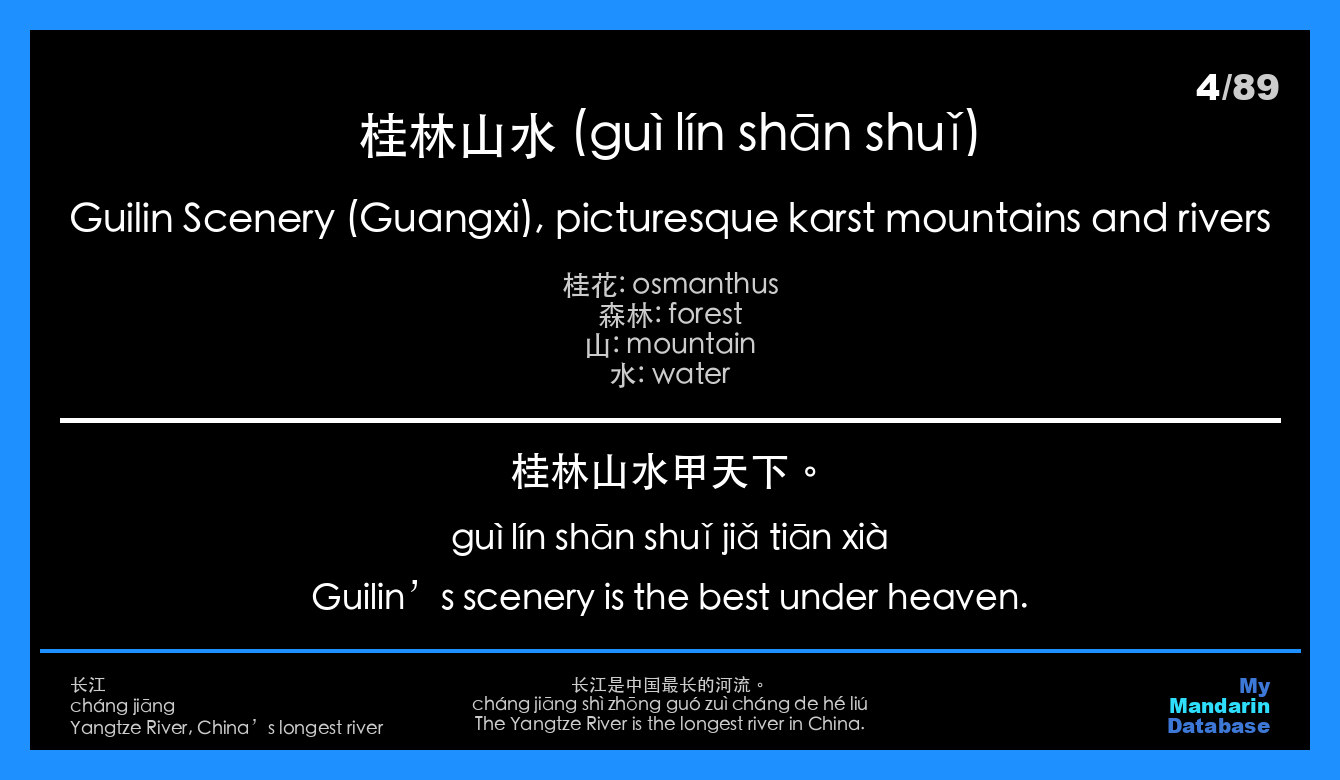

In [20]:
if 'icon_configs' in video_configs.keys():
    img = create_icon_from_slide(video_configs['icon_configs'], video_configs, project_artifacts_folder)
    img.save(f'{project_artifacts_folder}/icon.png')
    my_img = ImageClip(f"{project_artifacts_folder}/icon.png", duration=1).with_start(0)
my_img.display_in_notebook()

# 9. Create video

In [21]:
combine_clips_with_audio_to_create_video(clips, nonvocab_slides, project_artifacts_folder, data_settings)

intro
outro
Number of clips: 180
audio: 507.770s, video: 507.702s; difference: 0.068s
MoviePy - Building video output/videos/0101_cn_only_sent_china_tourist_attractions/video_china_tourist_attractions.mp4.
MoviePy - Writing audio in video_china_tourist_attractionsTEMP_MPY_wvf_snd.mp3


MoviePy - Done.
MoviePy - Writing video output/videos/0101_cn_only_sent_china_tourist_attractions/video_china_tourist_attractions.mp4



MoviePy - Done !
MoviePy - video ready output/videos/0101_cn_only_sent_china_tourist_attractions/video_china_tourist_attractions.mp4
